# Quickstart: NOAA GFS forecast and analysis, virtual - dynamical.org Icechunk Zarr

NOAA's Global Forecast System (GFS) is a global weather model on a 0.25° grid. These two virtual datasets carry the full GFS output from May 2021 to present, 274 variables in the forecast and 272 in the analysis, including 16 on 57 pressure levels and temperature and wind at 8 heights above mean sea level, by referencing NOAA's GRIB files rather than copying them. Each time step is one global field, so they suit map-oriented access. For long time series at a point, use the time-optimized [NOAA GFS forecast](https://dynamical.org/catalog/noaa-gfs-forecast/) and [NOAA GFS analysis](https://dynamical.org/catalog/noaa-gfs-analysis/), which carry the most used variables.

Dataset documentation:
- Forecast: https://dynamical.org/catalog/noaa-gfs-forecast-virtual/
- Analysis: https://dynamical.org/catalog/noaa-gfs-analysis-virtual/

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog cartopy

In [2]:
# TEMPORARY: these datasets are not in the dynamical.org catalog yet, so this cell opens their
# Icechunk stores directly. Once they are published, replace this whole cell with:
#
#     import dynamical_catalog
#
#     forecast = dynamical_catalog.open("noaa-gfs-forecast-virtual", chunks=None)
#     analysis = dynamical_catalog.open("noaa-gfs-analysis-virtual", chunks=None)
#     analysis_pressure = dynamical_catalog.open("noaa-gfs-analysis-virtual", group="pressure_level", chunks=None)
#     forecast
import icechunk
import xarray as xr


def open_virtual(dataset_id, **kwargs):
    # Chunks reference NOAA's public GFS archive, which icechunk must be allowed to read anonymously.
    authorize = icechunk.containers_credentials(
        {"s3://noaa-gfs-bdp-pds/": icechunk.s3_anonymous_credentials()}
    )
    storage = icechunk.s3_storage(
        bucket="dynamical-noaa-gfs", prefix=f"{dataset_id}/v0.1.0.icechunk", region="us-west-2", anonymous=True
    )
    repo = icechunk.Repository.open(storage, authorize_virtual_chunk_access=authorize)
    return xr.open_zarr(repo.readonly_session("main").store, consolidated=False, **kwargs)


forecast = open_virtual("noaa-gfs-forecast-virtual", chunks=None)
analysis = open_virtual("noaa-gfs-analysis-virtual", chunks=None)
analysis_pressure = open_virtual("noaa-gfs-analysis-virtual", group="pressure_level", chunks=None)
forecast

<xarray.Dataset> Size: 3PB
Dimensions:                                                  (init_time: 7864,
                                                              lead_time: 209,
                                                              latitude: 721,
                                                              longitude: 1440)
Coordinates:
  * init_time                                                (init_time) datetime64[ns] 63kB ...
    expected_forecast_length                                 (init_time) timedelta64[us] 63kB ...
  * lead_time                                                (lead_time) timedelta64[us] 2kB ...
    valid_time                                               (init_time, lead_time) datetime64[ns] 13MB ...
  * latitude                                                 (latitude) float64 6kB ...
  * longitude                                                (longitude) float64 12kB ...
    spatial_ref                                              int64 8B ...
Data variables: (12/255)
    albedo_surface                                           (init_time, lead_time, latitude, longitude) float64 14TB ...
    average_low_cloud_cover                                  (init_time, lead_time, latitude, longitude) float64 14TB ...
    average_medium_cloud_cover                               (init_time, lead_time, latitude, longitude) float64 14TB ...
    average_pressure_high_cloud_bottom                       (init_time, lead_time, latitude, longitude) float64 14TB ...
    average_pressure_high_cloud_top                          (init_time, lead_time, latitude, longitude) float64 14TB ...
    average_pressure_low_cloud_top                           (init_time, lead_time, latitude, longitude) float64 14TB ...
    ...                                                       ...
    wind_v_minus2pvu                                         (init_time, lead_time, latitude, longitude) float64 14TB ...
    wind_v_tropopause                                        (init_time, lead_time, latitude, longitude) float64 14TB ...
    wind_v_90_60mb                                           (init_time, lead_time, latitude, longitude) float64 14TB ...
    wind_v_minus1pvu                                         (init_time, lead_time, latitude, longitude) float64 14TB ...
    wind_v_minus0p5pvu                                       (init_time, lead_time, latitude, longitude) float64 14TB ...
    wind_v_planetary_boundary_layer                          (init_time, lead_time, latitude, longitude) float64 14TB ...
Attributes:
    dataset_id:           noaa-gfs-forecast-virtual
    dataset_version:      0.1.0
    name:                 NOAA GFS forecast, virtual
    description:          Weather forecasts from the Global Forecast System (...
    attribution:          NOAA NWS NCEP GFS data processed by dynamical.org f...
    license:              CC-BY-4.0
    spatial_domain:       Global
    spatial_resolution:   0.25 degrees (~20km)
    time_domain:          Forecasts initialized 2021-05-01 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 0-384 hours (0-16 days) ahead
    forecast_resolution:  Forecast step 0-120 hours: hourly, 123-384 hours: 3...

The forecast has two time dimensions: `init_time`, every 6 hours, and `lead_time`, hourly to 120 hours and then 3 hourly to 384 hours. `valid_time` combines them. The analysis is one hourly `time` dimension on the same grid, with the same variables except the two run-total precipitation accumulations, which only make sense from a forecast start.

Both datasets keep variables with a vertical dimension in two groups, `pressure_level` and `height_above_mean_sea_level`, opened with `group="pressure_level"` as above.

In [3]:
analysis

<xarray.Dataset> Size: 99TB
Dimensions:                                                  (time: 47182,
                                                              latitude: 721,
                                                              longitude: 1440)
Coordinates:
  * time                                                     (time) datetime64[ns] 377kB ...
  * latitude                                                 (latitude) float64 6kB ...
  * longitude                                                (longitude) float64 12kB ...
    spatial_ref                                              int64 8B ...
Data variables: (12/253)
    albedo_surface                                           (time, latitude, longitude) float64 392GB ...
    average_high_cloud_cover                                 (time, latitude, longitude) float64 392GB ...
    average_medium_cloud_cover                               (time, latitude, longitude) float64 392GB ...
    average_pressure_high_cloud_top                          (time, latitude, longitude) float64 392GB ...
    average_pressure_low_cloud_top                           (time, latitude, longitude) float64 392GB ...
    apparent_temperature_2m                                  (time, latitude, longitude) float64 392GB ...
    ...                                                       ...
    wind_v_planetary_boundary_layer                          (time, latitude, longitude) float64 392GB ...
    wind_v_90_60mb                                           (time, latitude, longitude) float64 392GB ...
    wind_v_minus1p5pvu                                       (time, latitude, longitude) float64 392GB ...
    wind_v_minus2pvu                                         (time, latitude, longitude) float64 392GB ...
    wind_v_max_wind                                          (time, latitude, longitude) float64 392GB ...
    wind_v_tropopause                                        (time, latitude, longitude) float64 392GB ...
Attributes:
    dataset_id:          noaa-gfs-analysis-virtual
    dataset_version:     0.1.0
    name:                NOAA GFS analysis, virtual
    description:         Weather analysis from the Global Forecast System (GF...
    attribution:         NOAA NWS NCEP GFS data processed by dynamical.org fr...
    license:             CC-BY-4.0
    spatial_domain:      Global
    spatial_resolution:  0.25 degrees (~20km)
    time_domain:         2021-05-01 00:00:00 UTC to Present
    time_resolution:     1 hour

### A map

Surface-based CAPE on the afternoon of the 31 March 2023 tornado outbreak, which produced more than 100 tornadoes from Arkansas to Ohio.

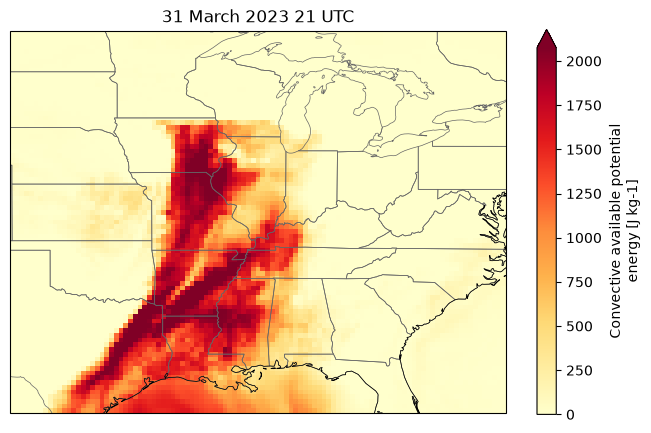

In [4]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

cape = (
    analysis["convective_available_potential_energy_surface"]
    .sel(time="2023-03-31T21", latitude=slice(48, 28), longitude=slice(-102, -76))
    .load()
)
plot = cape.plot(
    subplot_kws={"projection": ccrs.PlateCarree()},
    transform=ccrs.PlateCarree(), cmap="YlOrRd", center=False, robust=True, size=5, aspect=1.6,
)
ax = plot.axes
ax.add_feature(cfeature.STATES, edgecolor="0.4", linewidth=0.5)
ax.coastlines(linewidth=0.5)
ax.set_title("31 March 2023 21 UTC");

### A time series

A nor'easter deepened rapidly off New England on 29 January 2022 and spread snow from Virginia to Maine; Boston tied its record for snowfall in a single day. `snow_thickness_surface` is the model's snow depth for the 0.25° cell holding the city. The sudden drops are analysis cycles pulling the model's snowpack back toward observed depths.

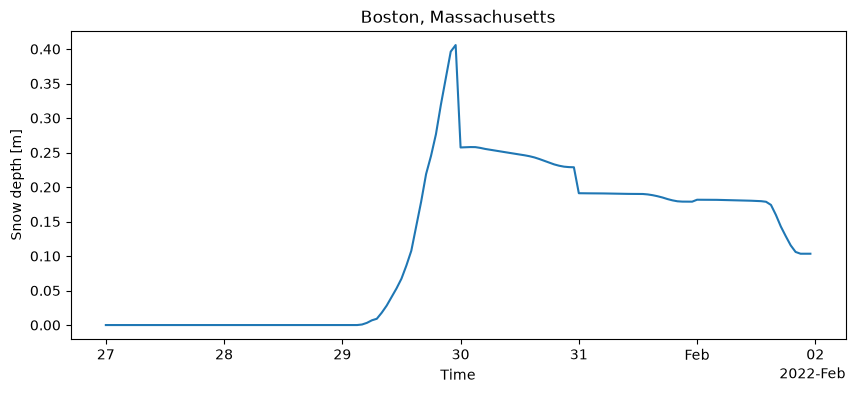

In [5]:
(
    analysis["snow_thickness_surface"]
    .sel(latitude=42.36, longitude=-71.06, method="nearest")
    .sel(time=slice("2022-01-27", "2022-02-01"))
    .plot(size=4, aspect=2.5)
)
plt.title("Boston, Massachusetts");

## How far ahead did the forecast carry Eunice's gusts?

Storm Eunice crossed southern England on 18 February 2022, and The Needles on the Isle of Wight recorded a 122 mph (55 m/s) gust. Forecasts initialized five, three and one day earlier are plotted against the analysis; the five-day forecast steps to 3 hourly beyond lead 120 hours.

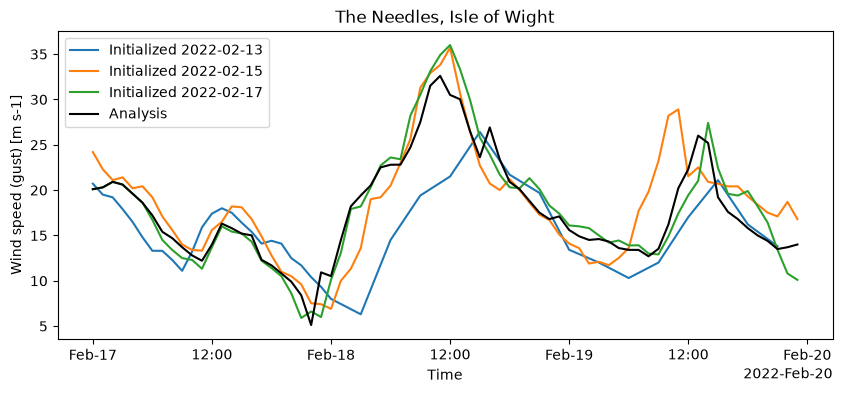

In [6]:
needles = dict(latitude=50.66, longitude=-1.58, method="nearest")
window = slice("2022-02-17", "2022-02-19T23")

fig, ax = plt.subplots(figsize=(10, 4))
for init_time in ["2022-02-13T00", "2022-02-15T00", "2022-02-17T00"]:
    gusts = (
        forecast["wind_gust_surface"]
        .sel(init_time=init_time, **needles)
        .swap_dims(lead_time="valid_time")
        .sel(valid_time=window)
        .load()
    )
    gusts.plot(ax=ax, label=f"Initialized {init_time[:10]}")
analysis["wind_gust_surface"].sel(**needles).sel(time=window).plot(ax=ax, color="black", label="Analysis")
ax.legend()
ax.set_title("The Needles, Isle of Wight");

## When did the stratospheric polar vortex reverse in February 2023?

A sudden stratospheric warming is declared when the zonal-mean westerly wind at 10 hPa and 60°N turns easterly. Reading every twelfth hour of the `pressure_level` group follows the reversal down through the stratosphere.

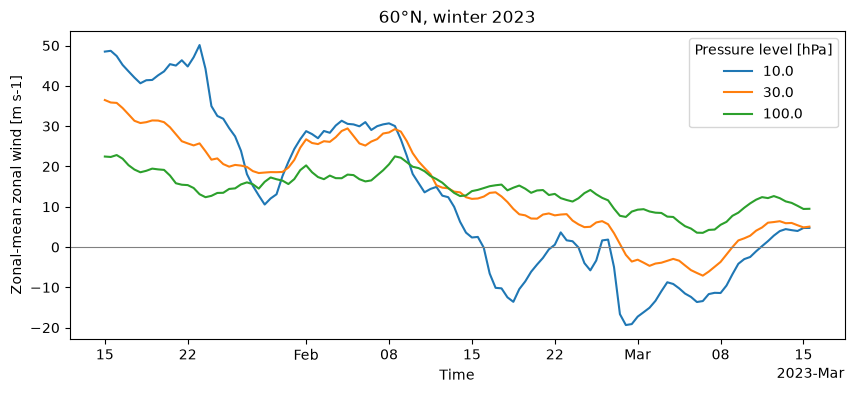

In [7]:
polar_wind = (
    analysis_pressure["wind_u"]
    .sel(pressure_level=[10, 30, 100], latitude=60)
    .sel(time=slice("2023-01-15", "2023-03-15"))
    .isel(time=slice(0, None, 12))
    .load()
    .mean("longitude", keep_attrs=True)
)
polar_wind.attrs["long_name"] = "Zonal-mean zonal wind"
polar_wind.plot(x="time", hue="pressure_level", size=4, aspect=2.5)
plt.axhline(0, color="0.5", linewidth=0.8)
plt.title("60°N, winter 2023");

## Animated: Hurricane Beryl crossing the Windward Islands

Beryl became the earliest Category 4 Atlantic hurricane on record on 30 June 2024 and crossed Carriacou on 1 July. The model's composite reflectivity follows the core and rainbands hour by hour.

In [8]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

beryl = (
    analysis["composite_reflectivity"]
    .sel(time=slice("2024-06-30T18", "2024-07-02T06"), latitude=slice(20, 6), longitude=slice(-70, -52))
    .load()
)
beryl = beryl.where(beryl > 5)

fig, ax = plt.subplots(figsize=(8, 5.5), dpi=72, subplot_kw={"projection": ccrs.PlateCarree()})
mesh = beryl.isel(time=0).plot(ax=ax, transform=ccrs.PlateCarree(), cmap="turbo", vmin=5, vmax=60)
ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="0.85", edgecolor="0.3", linewidth=0.6)


def draw_frame(i):
    mesh.set_array(beryl.isel(time=i).values.ravel())
    ax.set_title(str(beryl.time.values[i])[:16])


anim = FuncAnimation(fig, draw_frame, frames=beryl.sizes["time"], interval=250)
plt.close(fig)
HTML(anim.to_jshtml())

## Community challenge

- Which fields does the forecast get right first? Compare `wind_gust_surface`, `composite_reflectivity` and `convective_available_potential_energy_surface` at matching valid times across lead times for a season of storms.
- The `height_above_mean_sea_level` group carries temperature and wind at eight aviation heights from 305 m to 4572 m. Where and when does the analysis show icing conditions, and how far ahead does the forecast see them?
- Soil moisture and temperature are stored in four layers down to 2 m. How quickly do model soils dry out during a flash drought, and does the forecast anticipate it?
- With 57 pressure levels up to 0.01 hPa, how often did the polar vortex reverse in other winters since 2021, and how did each event propagate downward?